# Modelaje y presentación de resultados.

Aquí haremos un showcase de los resultados. Usamos Programación Orientada a Objetos para dejar acomodados de forma más ordenada los distintos modelos y resultados. Al final haremos una tabla comparativa.

Primero, cargaremos nuestra clase `compareModels` la cual tiene los métodos para hacer la predicción. También en dicha clase se encuentra los métodos para hacer `GridSearchCV`. Se encuentran métodos para hacer gráficos también.

In [1]:
import sys
sys.path.insert(0, '..')     
from modelaje import compareModels

comparacion = compareModels()
comparacion.dependent_variable

{'uci_id': 560, 'name': 'Seoul Bike Sharing Demand', 'repository_url': 'https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand', 'data_url': 'https://archive.ics.uci.edu/static/public/560/data.csv', 'abstract': 'The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 8760, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Functioning Day'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5F62R', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and a

'Rented Bike Count'

## Regresión Lineal

In [2]:
y_pred,linear_regressor = comparacion.linear_regression()

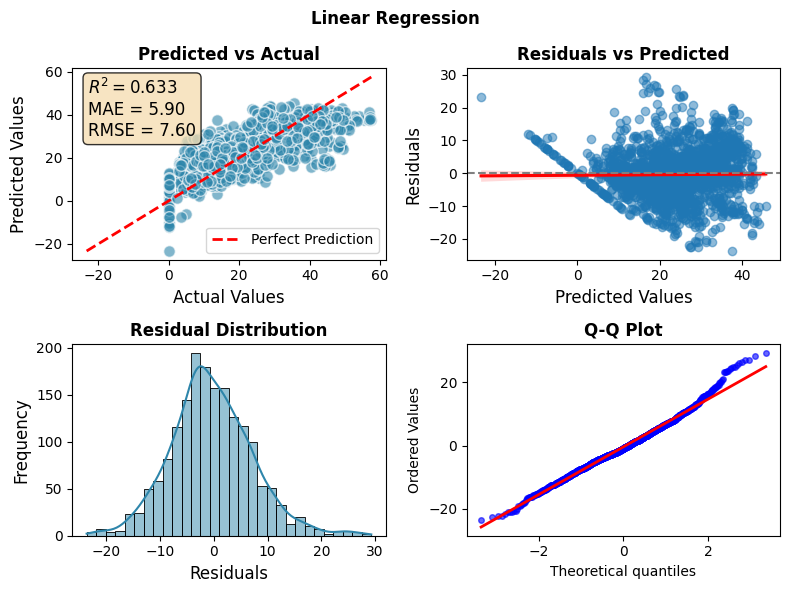

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Linear Regression,5.9045,57.7927,7.6021,0.633,0.6288


In [3]:
comparacion.plot_results(y_pred,"Linear Regression")
comparacion.create_entry(y_pred,"Linear Regression",comparacion.comparison_table)


## Lasso

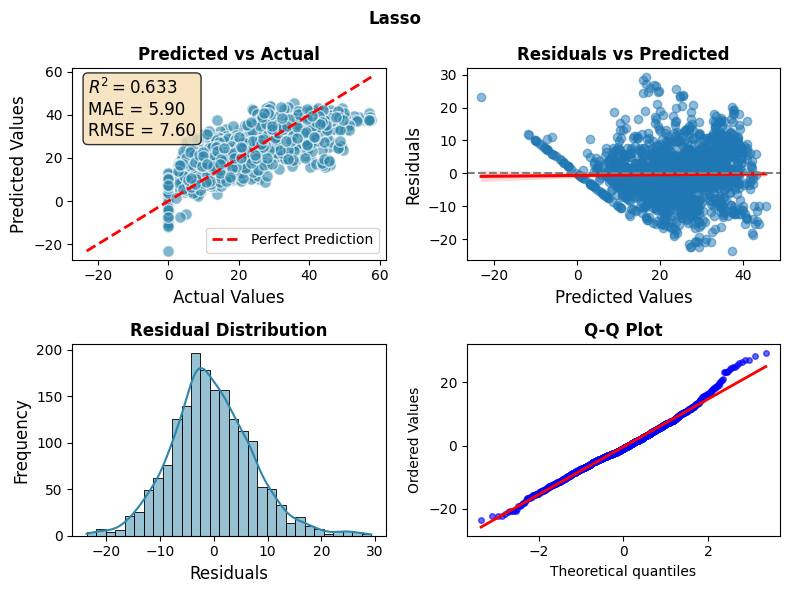

In [4]:
y_pred,lasso = comparacion.lasso()
comparacion.create_entry(y_pred,"Lasso",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Lasso")


## Ridge

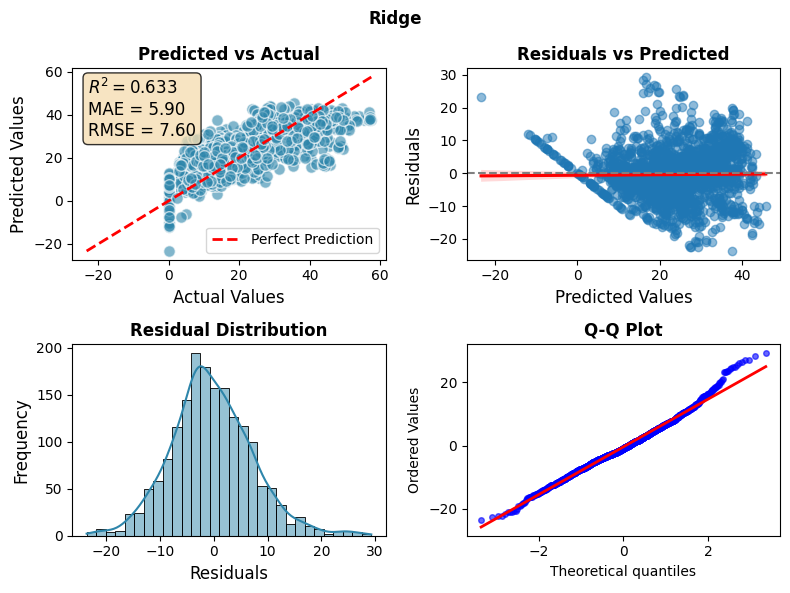

In [5]:
y_pred,ridge = comparacion.ridge()
comparacion.create_entry(y_pred,"Ridge",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Ridge")


## Elastic Net

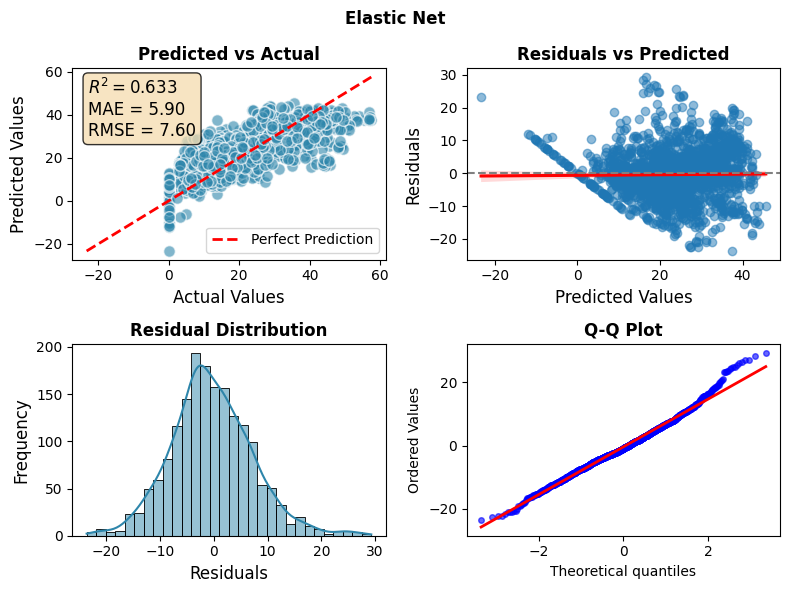

In [6]:
y_pred,elastic_net= comparacion.elastic_net()
comparacion.create_entry(y_pred,"Elastic Net",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Elastic Net")


## Decision Tree

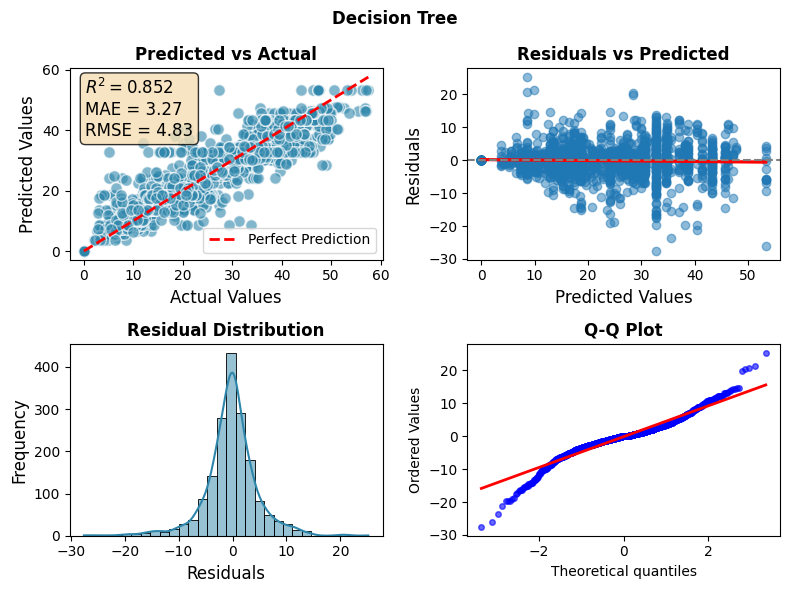

In [7]:
y_pred,decision_tree = comparacion.decision_tree()
comparacion.create_entry(y_pred,"Decision Tree",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Decision Tree")


## Random Forest

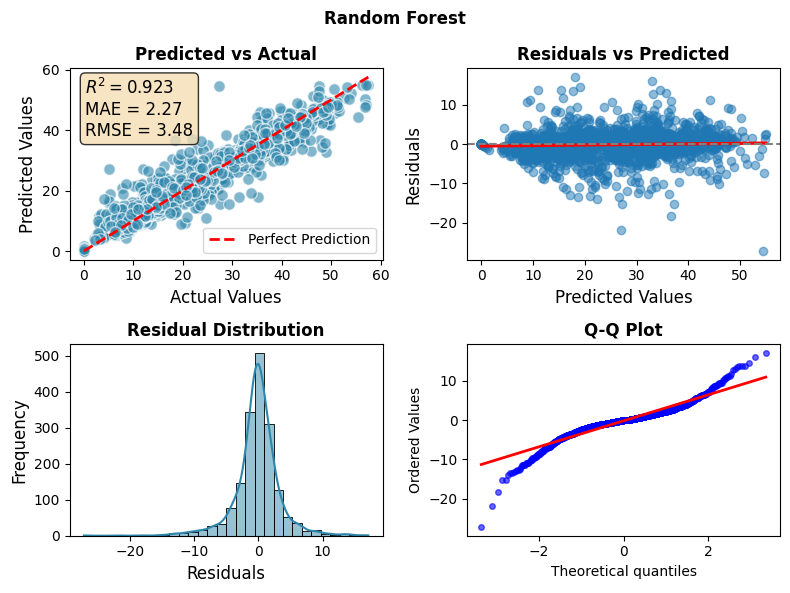

In [8]:
y_pred,random_forest = comparacion.random_forest()
comparacion.create_entry(y_pred,"Random Forest",comparacion.comparison_table)

comparacion.plot_results(y_pred,"Random Forest")

## Gradient Boosting

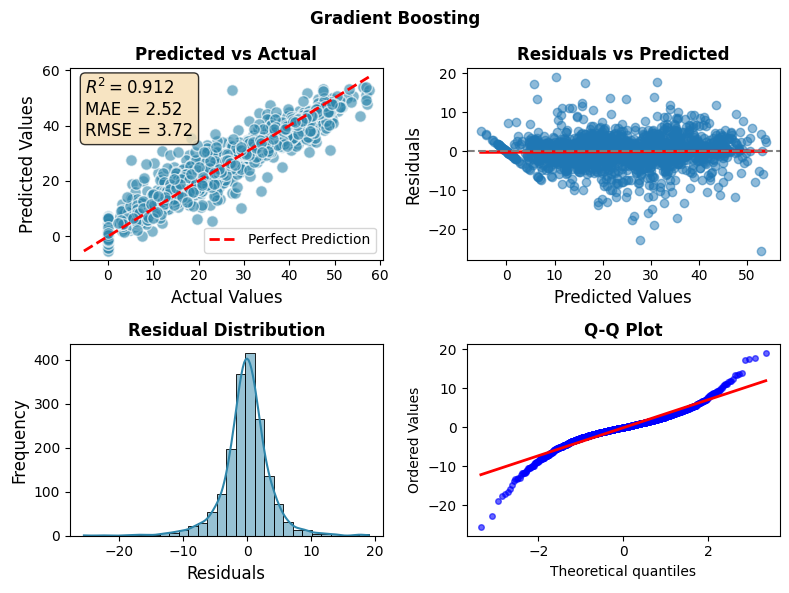

In [9]:
y_pred,gradient_boosting = comparacion.gradient_boosting()
comparacion.create_entry(y_pred,"Gradient Boosting",comparacion.comparison_table)
comparacion.plot_results(y_pred,"Gradient Boosting")


## Modelos de Redes
Vamos a usar los siguientes modelos de redes e incluirlos en nuestra tabla: `AdaBoost`, `XGBoost` y para el Perceptrón Multicapa usaremos `MLP`.

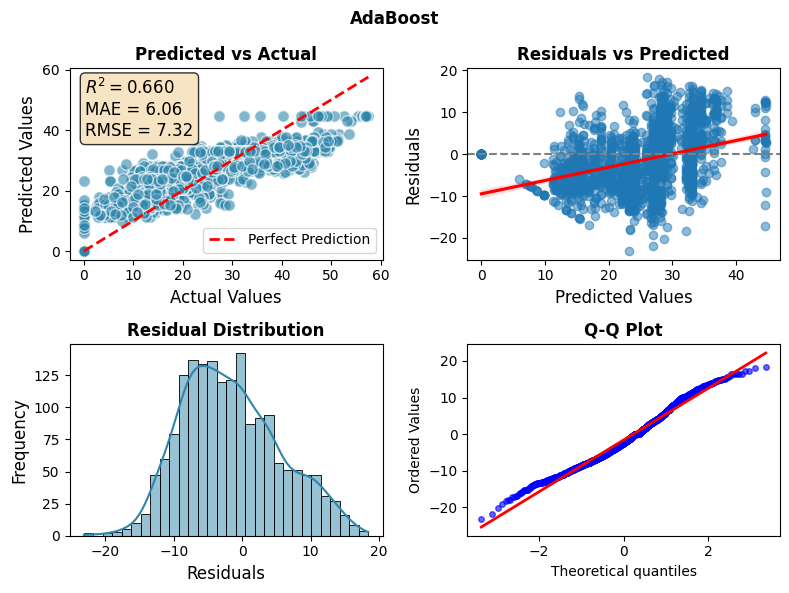

In [10]:
y_pred,ada_boost = comparacion.ada_boost()
comparacion.create_entry(y_pred,"AdaBoost",comparacion.comparison_table)
comparacion.plot_results(y_pred,"AdaBoost")

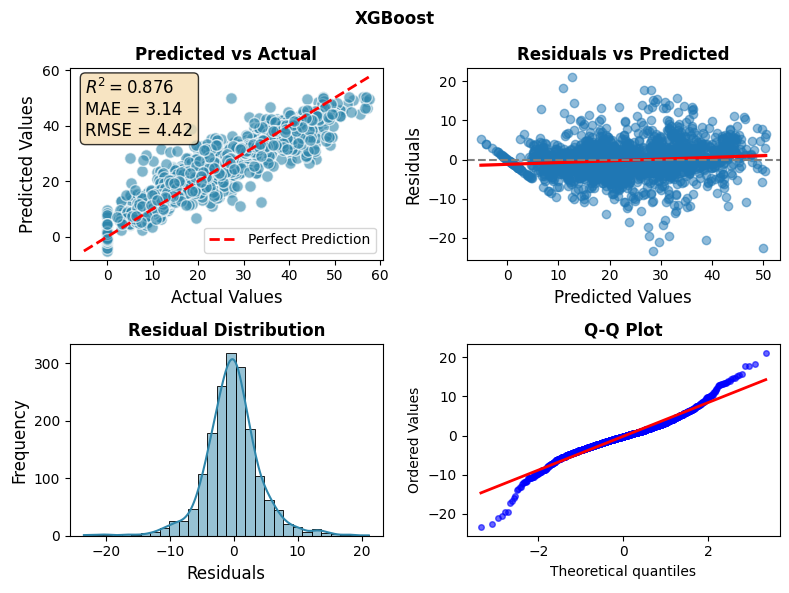

In [11]:
y_pred,xgboost = comparacion.xg_boost()
comparacion.create_entry(y_pred,"XGBoost",comparacion.comparison_table)
comparacion.plot_results(y_pred,"XGBoost")

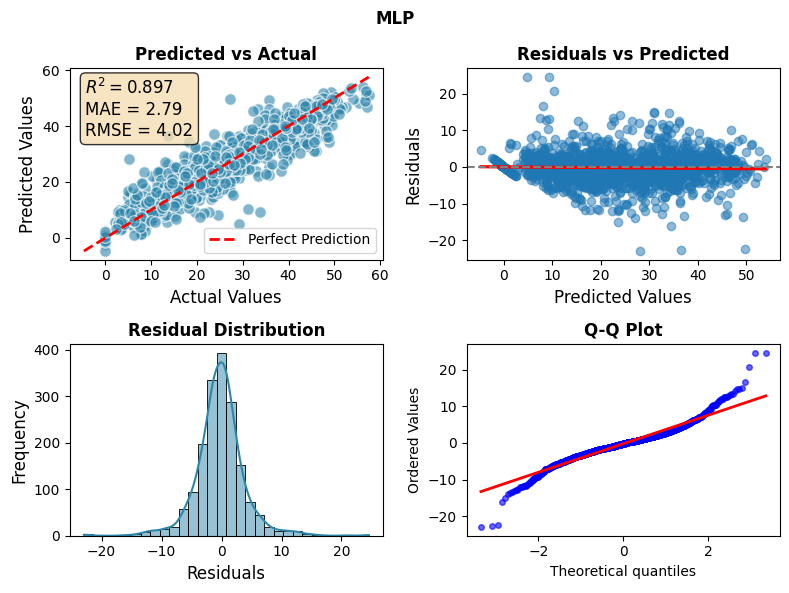

In [12]:
y_pred,mlp = comparacion.mlp_regressor()
comparacion.create_entry(y_pred,"MLP",comparacion.comparison_table)
comparacion.plot_results(y_pred,"MLP")

## Resultados (Sin GridSearchCV)

La siguiente tabla muestra los resultados de los distintos modelos, sin hacer uso de `GridSearchCV`

In [13]:
comparacion.comparison_table.sort_values(by='Adjusted_R2', ascending=False)

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
5,Random Forest,2.2659,12.1408,3.4844,0.9229,0.9220
6,Gradient Boosting,2.5243,13.8322,3.7192,0.9122,0.9112
9,MLP,2.7898,16.1744,4.0217,0.8973,0.8961
8,XGBoost,3.1443,19.5394,4.4203,0.8759,0.8745
4,Decision Tree,3.2715,23.3649,4.8337,0.8516,0.8499
7,AdaBoost,6.0601,53.5173,7.3156,0.6602,0.6563
2,Ridge,5.9045,57.7927,7.6021,0.6330,0.6288
0,Linear Regression,5.9045,57.7927,7.6021,0.6330,0.6288
3,Elastic Net,5.9045,57.7956,7.6023,0.6330,0.6288
1,Lasso,5.9041,57.8277,7.6045,0.6328,0.6286


Como podemos ver, los mejores modelos resultaron ser `Random Forest` y `Gradient Boosting`. Pero, no hemos optimizado los parámetros aún. Procedemos a usar `GridSearchCV`. La siguiente función buscará los mejores parámetros para todos los modelos, regresara un diccionario con los parámetros para cada modelo. 

In [14]:
import json

with open('best_params.json', 'r') as f:
    best_params_dict = json.load(f)



La siguiente función extraerá los parametros y correrá los modelos con dichos parametros.

In [15]:
y_predictions,best_params = comparacion.re_run_with_better_params(best_params_dict)


In [16]:
y_predictions_2,best_params_2 = comparacion.re_run_with_better_params()


{'lasso': GridSearchCV(cv=5, estimator=Lasso(max_iter=10000),
             param_grid={'alpha': array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03, 6.86648845e-03,
       9.10298178e-03, 1.20679264e-02, 1.5...
       8.68511374e-02, 1.15139540e-01, 1.52641797e-01, 2.02358965e-01,
       2.68269580e-01, 3.55648031e-01, 4.71486636e-01, 6.25055193e-01,
       8.28642773e-01, 1.09854114e+00, 1.45634848e+00, 1.93069773e+00,
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02])},
             scoring='r2'), 'ridge': GridSearchCV(cv=5, estimator=Ridge(max_iter=10000),
             para

In [17]:
import pandas as pd
rows = []
for model, params in best_params.items():
    params2 = best_params_2.get(model, {})
    for param_name, value1 in params.items():
        value2 = params2.get(param_name, 'N/A')
        rows.append({
            'Model': model,
            'Parameter': param_name,
            'best_params': value1,
            'best_params2': value2
        })

# Create DataFrame and print as table
df = pd.DataFrame(rows)
df

,Model,Parameter,best_params,best_params2
0,lasso,alpha,0.002947,0.002947
1,ridge,alpha,18.4207,18.4207
2,elastic_net,alpha,0.003907,0.003907
3,elastic_net,l1_ratio,0.28,0.28
4,decision_tree,max_depth,15,15
5,decision_tree,min_samples_leaf,2,2
6,decision_tree,min_samples_split,20,20
7,random_forest,max_depth,None,None
8,random_forest,min_samples_split,2,2
9,random_forest,n_estimators,200,200


Como podemos ver arriba, conseguimos los mismos datos debido a la semilla.

Esta función toma 20 minutos aproximadamente, vamos a guardar los parametros para siguientes ejecuciones.

In [18]:
# import json
# best_params_clean = {name: gs_ for name, gs in best_params.items()}
# with open('best_params.json', 'w') as f:
#     json.dump(best_params_clean, f, indent=2)

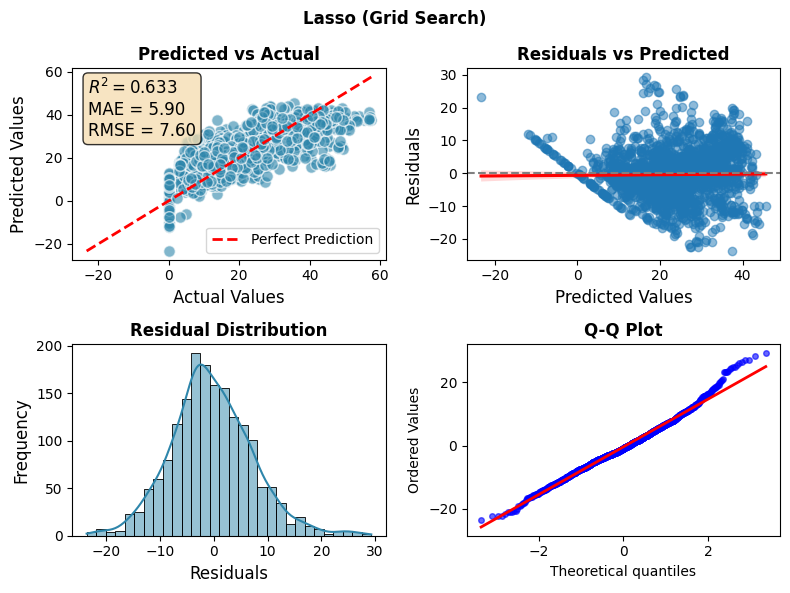

In [19]:
comparacion.plot_results(y_predictions["lasso"],"Lasso (Grid Search)")


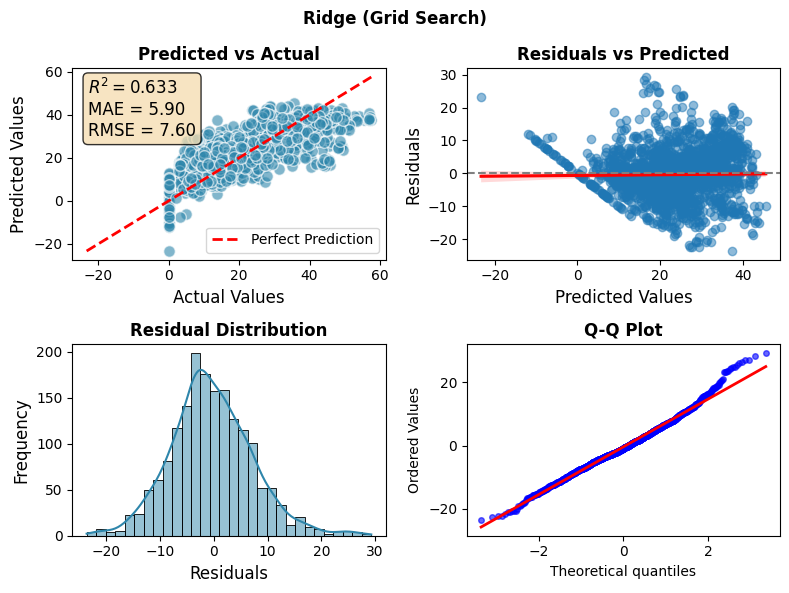

In [20]:
comparacion.plot_results(y_predictions["ridge"],"Ridge (Grid Search)")


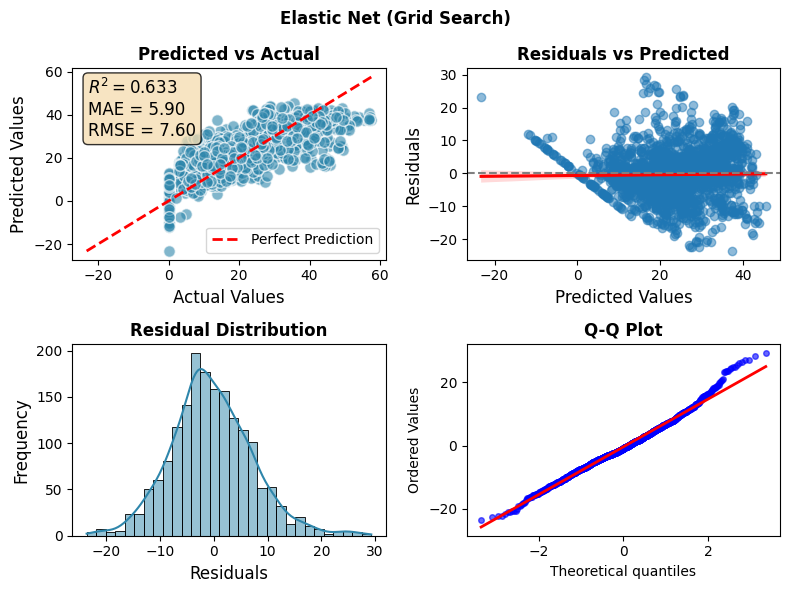

In [21]:
comparacion.plot_results(y_predictions["elastic_net"],"Elastic Net (Grid Search)")


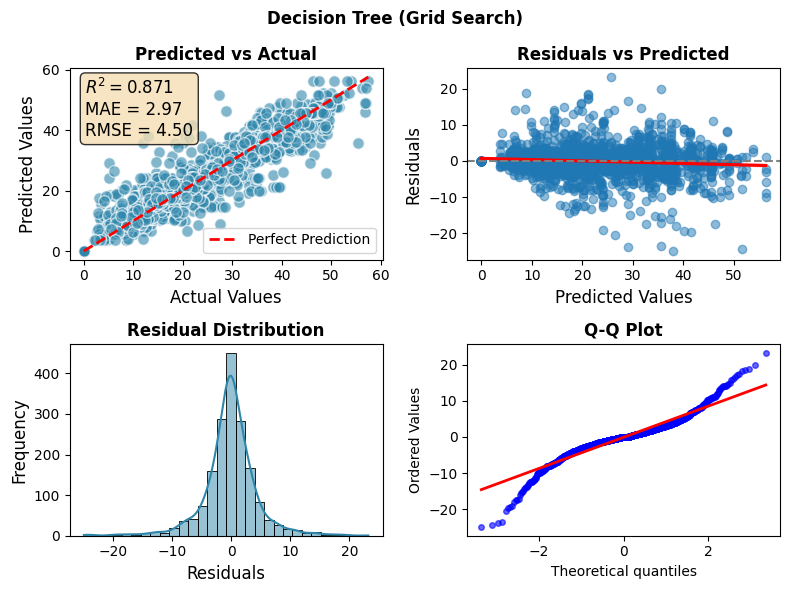

In [22]:
comparacion.plot_results(y_predictions["decision_tree"],"Decision Tree (Grid Search)")


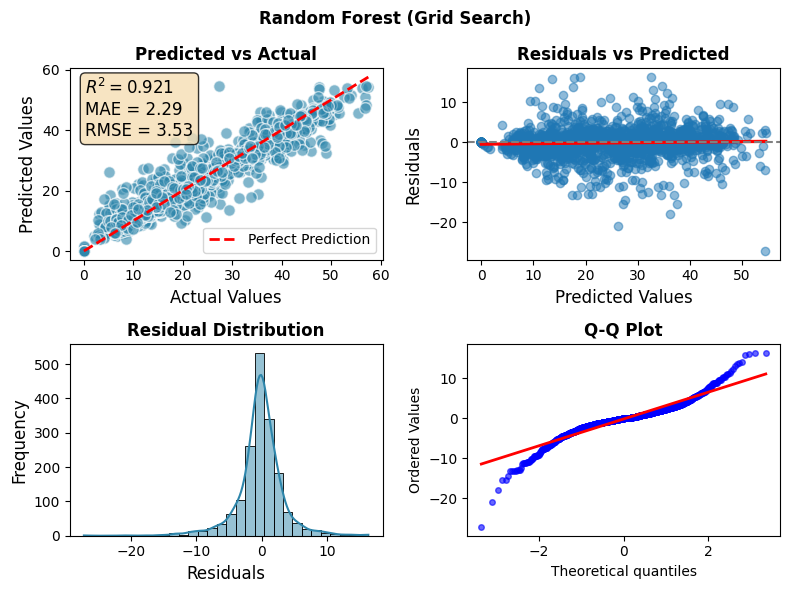

In [23]:
comparacion.plot_results(y_predictions["random_forest"],"Random Forest (Grid Search)")


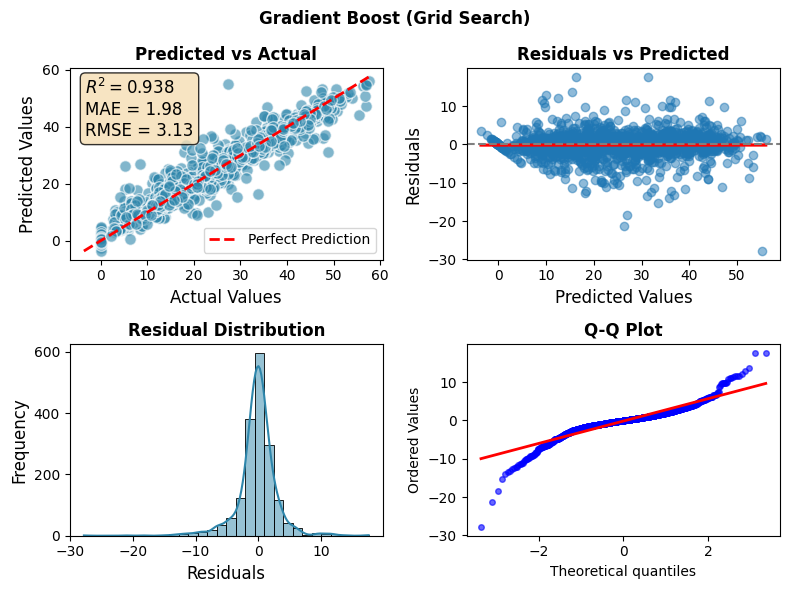

In [24]:
comparacion.plot_results(y_predictions["gradient_boost"],"Gradient Boost (Grid Search)")


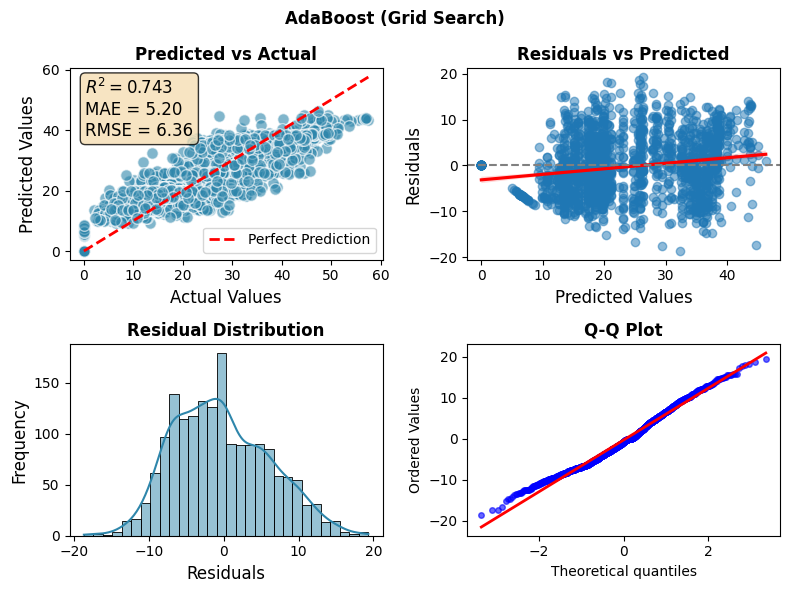

In [25]:
comparacion.plot_results(y_predictions["ada_boost"],"AdaBoost (Grid Search)")

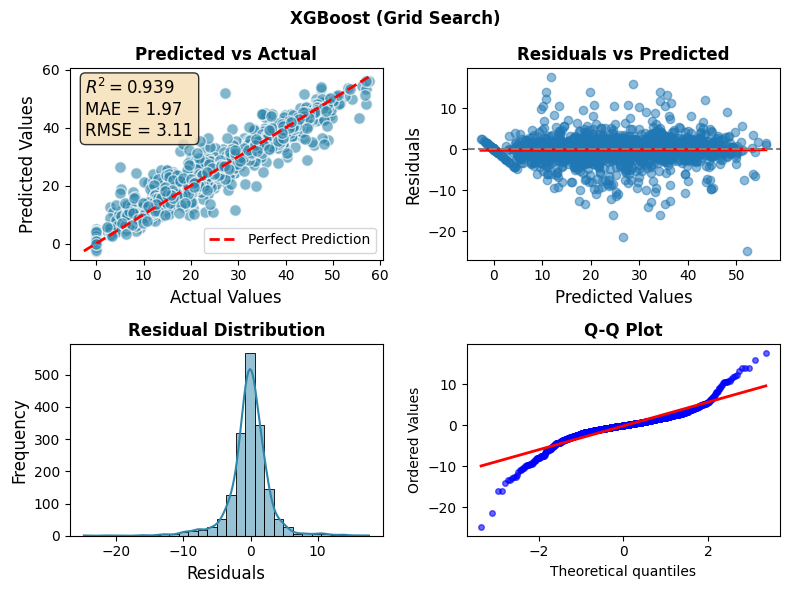

In [26]:
comparacion.plot_results(y_predictions["xgboost"],"XGBoost (Grid Search)")

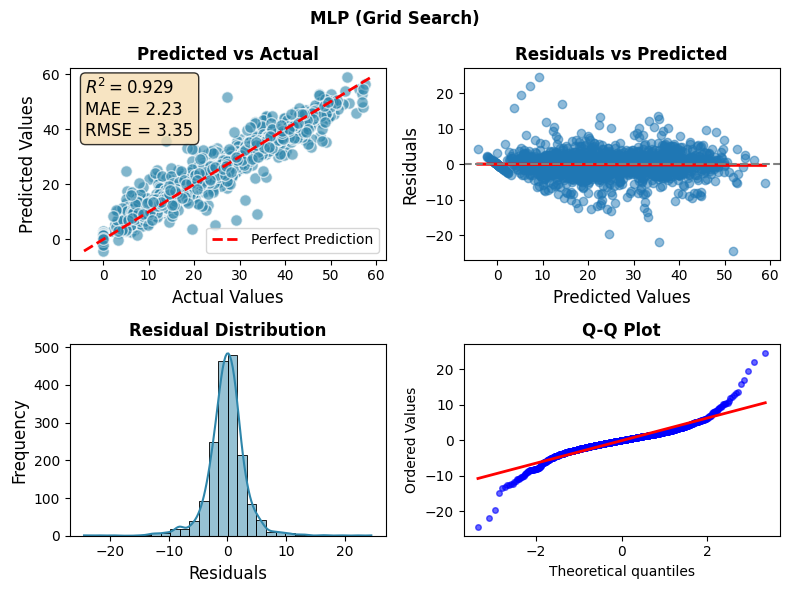

In [27]:
comparacion.plot_results(y_predictions["mlp"],"MLP (Grid Search)")

## Comparativa de resultados

A continuación, una comparación entre ambas tablas, la primera es con `GridSearchCV`:

In [47]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287
1,Ridge (Grid Search),5.9048,57.8014,7.6027,0.6330,0.6287
2,Elastic Net (Grid Search),5.9047,57.8055,7.6030,0.6329,0.6287
3,Decision Tree (Grid Search),2.9668,20.2706,4.5023,0.8713,0.8698
4,Random Forest (Grid Search),2.2902,12.4334,3.5261,0.9211,0.9201
5,Gradient Boost (Grid Search),1.9848,9.7954,3.1298,0.9378,0.9371
6,AdaBoost (Grid Search),5.1952,40.3955,6.3557,0.7435,0.7405
7,XGBoost (Grid Search),1.9682,9.6593,3.1079,0.9387,0.9380
8,MLP (Grid Search),2.2278,11.2328,3.3515,0.9287,0.9279
9,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287


In [29]:
comparacion.comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Linear Regression,5.9045,57.7927,7.6021,0.6330,0.6288
1,Lasso,5.9041,57.8277,7.6045,0.6328,0.6286
2,Ridge,5.9045,57.7927,7.6021,0.6330,0.6288
3,Elastic Net,5.9045,57.7956,7.6023,0.6330,0.6288
4,Decision Tree,3.2715,23.3649,4.8337,0.8516,0.8499
5,Random Forest,2.2659,12.1408,3.4844,0.9229,0.9220
6,Gradient Boosting,2.5243,13.8322,3.7192,0.9122,0.9112
7,AdaBoost,6.0601,53.5173,7.3156,0.6602,0.6563
8,XGBoost,3.1443,19.5394,4.4203,0.8759,0.8745
9,MLP,2.7898,16.1744,4.0217,0.8973,0.8961


Podemos notar que el `GridSearch` sí mejoró los resultados. Random Forest ya era bueno asi que las mejoras fueron pequeñas. `Gradient Boosting` mejoró significamente.Pero quien se llevó la mejora más significativa fue `XGBoost` convirtiendose en el nuevo campeón. Son estos dos los mejores de todos los modelos usados.Las features con más peso fueron:

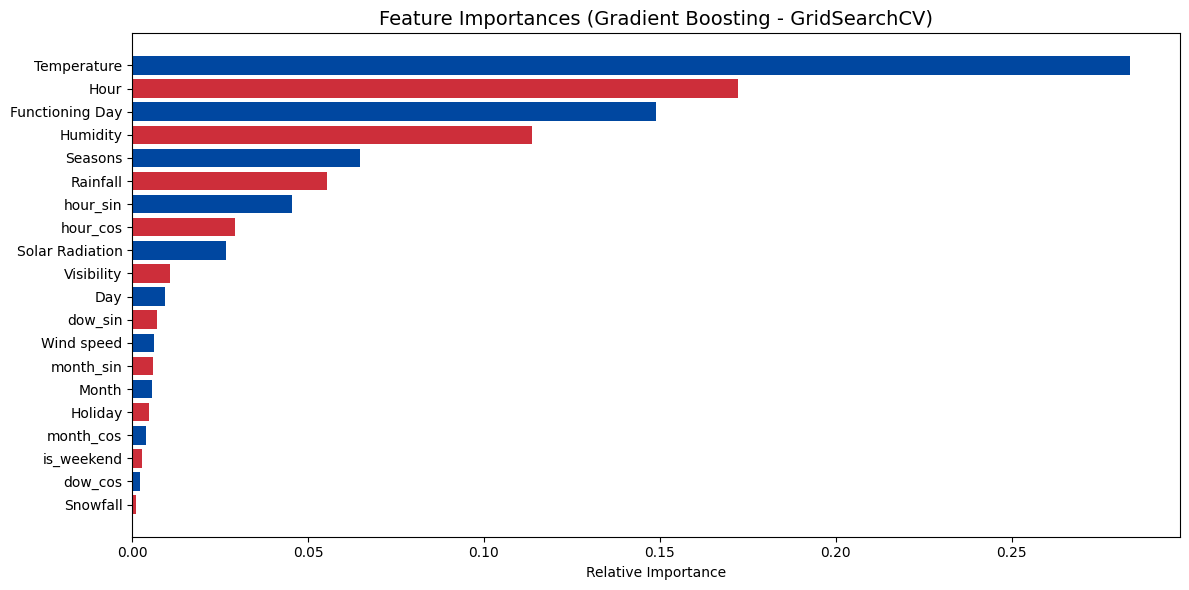

In [30]:
comparacion.most_important_features()

## GLM Poisson: Justificación

Nuestra variable target está compuesto de enteros no negativos: 

In [31]:
comparacion.dataframe["Rented Bike Count"][0:10]

0    254
1    204
2    173
3    107
4     78
5    100
6    181
7    460
8    930
9    490
Name: Rented Bike Count, dtype: int64

Una regresión lineal estandar incorrectamente intentaría predecir valores negativos y además, la regresión lineal estándar asume **homoscedasticidad**. Como nuestra variable target es un conteo, esta suposición **no** se cumple, ya que la varianza crece con la media.


De hecho, podemos notar en los gráficos de arriba ese patrón de **heteroscedasticidad** con los residuales, como por ejemplo:


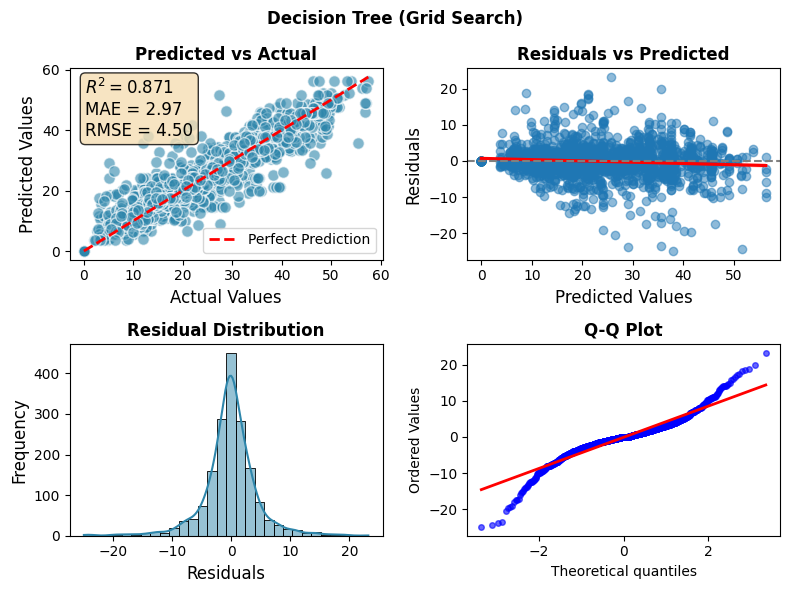

In [32]:
comparacion.plot_results(y_predictions["decision_tree"],"Decision Tree (Grid Search)")


Ahora, un modelo `GLM Poisson` modela el logaritmo de la media y explicitamente asume que la varianza es igual a la media, usa un esquema de pesos ponderados. Esto en teoría debería resolver el problema de **heteroscedasticidad**. Para prestarle atención a la estacionalidad temporal, hicimos lo siguiente con el dataframe en la etapa de limpieza:

In [33]:
import numpy as np
def make_sin_cos(self):
        self.dataframe['hour_sin'] = np.sin(2 * np.pi * self.dataframe['Hour'] / 24)
        self.dataframe['hour_cos'] = np.cos(2 * np.pi * self.dataframe['Hour'] / 24)
        self.dataframe['dow_sin'] = np.sin(2 * np.pi * self.dataframe['Day'] / 7)
        self.dataframe['dow_cos'] = np.cos(2 * np.pi * self.dataframe['Day'] / 7)

        self.dataframe['month_sin'] = np.sin(2 * np.pi * self.dataframe['Month'] / 12)
        self.dataframe['month_cos'] = np.cos(2 * np.pi * self.dataframe['Month'] / 12)

Esta función nos ayuda a incluir esta información de estacionalidad temporal, puesto que la hora 23 estaría "cerca" de la hora 0. Esto ayudará a que `GLM Poisson` tome en cuenta los "picos" de demanda de las 8:00AM y 6:00PM que notamos en el EDA. De no incluir lo de arriba, el modelo buscaría una tendencia monotona , lo cual no brinda mucha información ni es representativo de lo que pasa en la vida real.

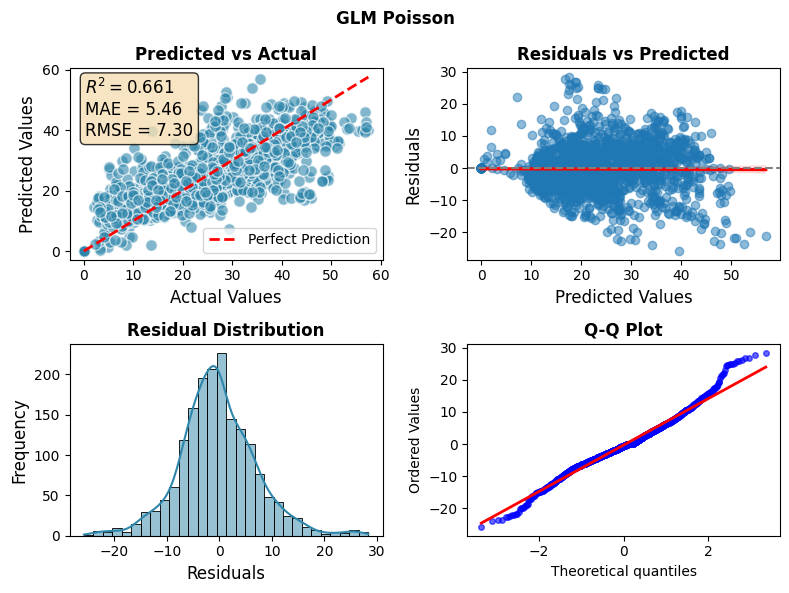

In [34]:
y_pred,poisson = comparacion.poisson_GLM()
comparacion.create_entry(y_pred,"GLM Poisson",comparacion.grid_search_comparison_table)
comparacion.plot_results(y_pred,"GLM Poisson")

In [35]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287
1,Ridge (Grid Search),5.9048,57.8014,7.6027,0.6330,0.6287
2,Elastic Net (Grid Search),5.9047,57.8055,7.6030,0.6329,0.6287
3,Decision Tree (Grid Search),2.9668,20.2706,4.5023,0.8713,0.8698
4,Random Forest (Grid Search),2.2902,12.4334,3.5261,0.9211,0.9201
5,Gradient Boost (Grid Search),1.9848,9.7954,3.1298,0.9378,0.9371
6,AdaBoost (Grid Search),5.1952,40.3955,6.3557,0.7435,0.7405
7,XGBoost (Grid Search),1.9682,9.6593,3.1079,0.9387,0.9380
8,MLP (Grid Search),2.2278,11.2328,3.3515,0.9287,0.9279
9,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287


Parece no haber vencido al Gradient Boost o a Random Forest. Intentaremos usar statsmodel para ver si cambia algo:

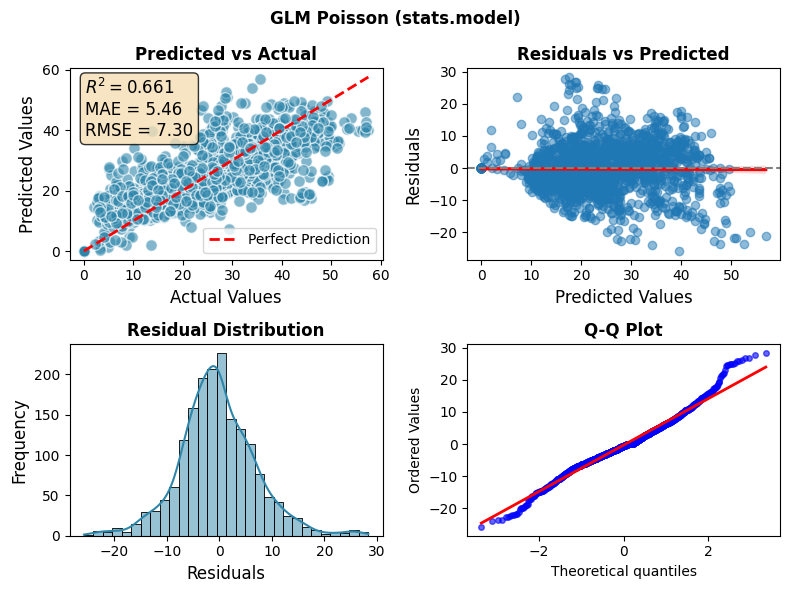

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287
1,Ridge (Grid Search),5.9048,57.8014,7.6027,0.6330,0.6287
2,Elastic Net (Grid Search),5.9047,57.8055,7.6030,0.6329,0.6287
3,Decision Tree (Grid Search),2.9668,20.2706,4.5023,0.8713,0.8698
4,Random Forest (Grid Search),2.2902,12.4334,3.5261,0.9211,0.9201
5,Gradient Boost (Grid Search),1.9848,9.7954,3.1298,0.9378,0.9371
6,AdaBoost (Grid Search),5.1952,40.3955,6.3557,0.7435,0.7405
7,XGBoost (Grid Search),1.9682,9.6593,3.1079,0.9387,0.9380
8,MLP (Grid Search),2.2278,11.2328,3.3515,0.9287,0.9279
9,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287


In [36]:
import statsmodels.api as sm
new_X_train = comparacion.X_train.astype(float)
new_X_test = comparacion.X_test.astype(float)
# Add constant and fit
X_train_const = sm.add_constant(new_X_train)
poisson_sm = sm.GLM(comparacion.y_train, X_train_const, family=sm.families.Poisson()).fit()

# Check predictions on test
X_test_const = sm.add_constant(new_X_test)
y_pred_sm = poisson_sm.predict(X_test_const)
comparacion.plot_results(y_pred_sm,"GLM Poisson (stats.model)")
comparacion.create_entry(y_pred_sm,"GLM Poisson (stats.model) ",comparacion.grid_search_comparison_table)



Parece no ayudar mucho. Ahora intentaremos una Binomial Negativa.

/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.test_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3663: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.test_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.test_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3470: RuntimeWarning: overflow encountered in multiply
  dparams = exog*a1 * (y-mu)/(mu+a1)
/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/proyecto_modulo_5/.test_env/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3470: RuntimeWarning: invalid value encountered in multiply
  dparams = exog*a1 * (y-mu)/(mu

         Current function value: 4.042500
         Iterations: 0
         Function evaluations: 13
         Gradient evaluations: 2


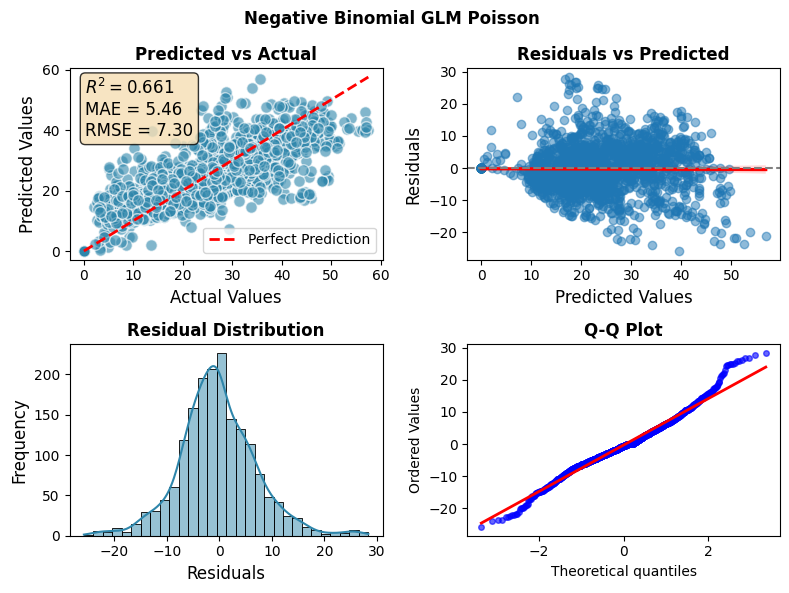

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287
1,Ridge (Grid Search),5.9048,57.8014,7.6027,0.6330,0.6287
2,Elastic Net (Grid Search),5.9047,57.8055,7.6030,0.6329,0.6287
3,Decision Tree (Grid Search),2.9668,20.2706,4.5023,0.8713,0.8698
4,Random Forest (Grid Search),2.2902,12.4334,3.5261,0.9211,0.9201
5,Gradient Boost (Grid Search),1.9848,9.7954,3.1298,0.9378,0.9371
6,AdaBoost (Grid Search),5.1952,40.3955,6.3557,0.7435,0.7405
7,XGBoost (Grid Search),1.9682,9.6593,3.1079,0.9387,0.9380
8,MLP (Grid Search),2.2278,11.2328,3.3515,0.9287,0.9279
9,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287


In [37]:
from statsmodels.discrete.discrete_model import NegativeBinomial
new_X_train = comparacion.X_train.astype(float)
new_X_test = comparacion.X_test.astype(float)
nb_model = NegativeBinomial(comparacion.y_train, X_train_const).fit()
y_pred_nb = nb_model.predict(X_test_const)
comparacion.plot_results(y_pred_nb,"Negative Binomial GLM Poisson ")
comparacion.create_entry(y_pred_nb,"Negative Binomial GLM",comparacion.grid_search_comparison_table)

In [38]:
comparacion.grid_search_comparison_table

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287
1,Ridge (Grid Search),5.9048,57.8014,7.6027,0.6330,0.6287
2,Elastic Net (Grid Search),5.9047,57.8055,7.6030,0.6329,0.6287
3,Decision Tree (Grid Search),2.9668,20.2706,4.5023,0.8713,0.8698
4,Random Forest (Grid Search),2.2902,12.4334,3.5261,0.9211,0.9201
5,Gradient Boost (Grid Search),1.9848,9.7954,3.1298,0.9378,0.9371
6,AdaBoost (Grid Search),5.1952,40.3955,6.3557,0.7435,0.7405
7,XGBoost (Grid Search),1.9682,9.6593,3.1079,0.9387,0.9380
8,MLP (Grid Search),2.2278,11.2328,3.3515,0.9287,0.9279
9,Lasso (Grid Search),5.9042,57.8010,7.6027,0.6330,0.6287


De los mejores modelos, vamos a comparar `MAE` vs `MSE`, empecemos con `GradientBoost` ya que admite un parametro `loss` para especificar `MAE` o `MSE`. 

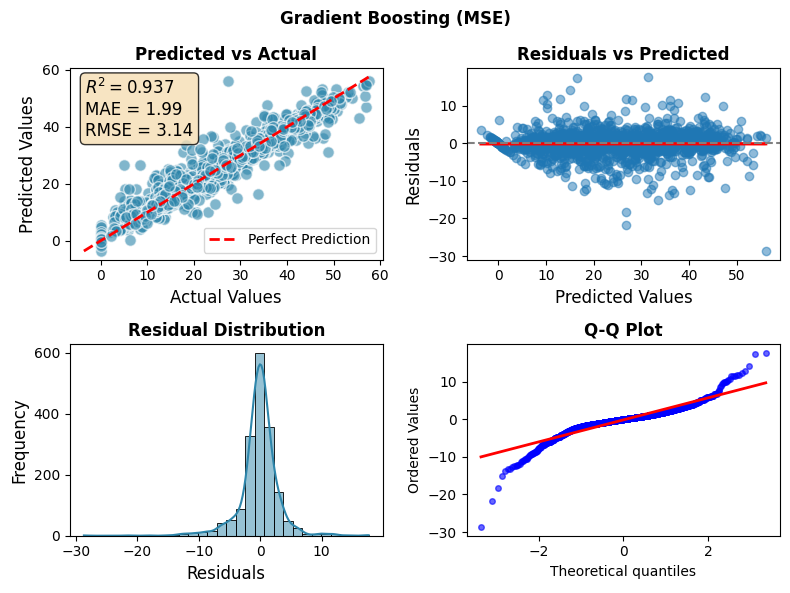

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Gradient Boosting (MSE),1.9903,9.868,3.1413,0.9373,0.9366


In [39]:
import pandas as pd
tabla_comparativa_gradientboost = pd.DataFrame(columns=comparacion.columns_table)
y_pred,gradient_boosting = comparacion.gradient_boosting(
                                                    best_params["gradient_boost"]["learning_rate"],
                                                    best_params["gradient_boost"]["max_depth"],
                                                    best_params["gradient_boost"]["n_estimators"],
                                                    loss="squared_error")
tabla_comparativa_gradientboost=comparacion.create_entry(y_pred,"Gradient Boosting (MSE)",tabla_comparativa_gradientboost)
comparacion.plot_results(y_pred,"Gradient Boosting (MSE)")
tabla_comparativa_gradientboost


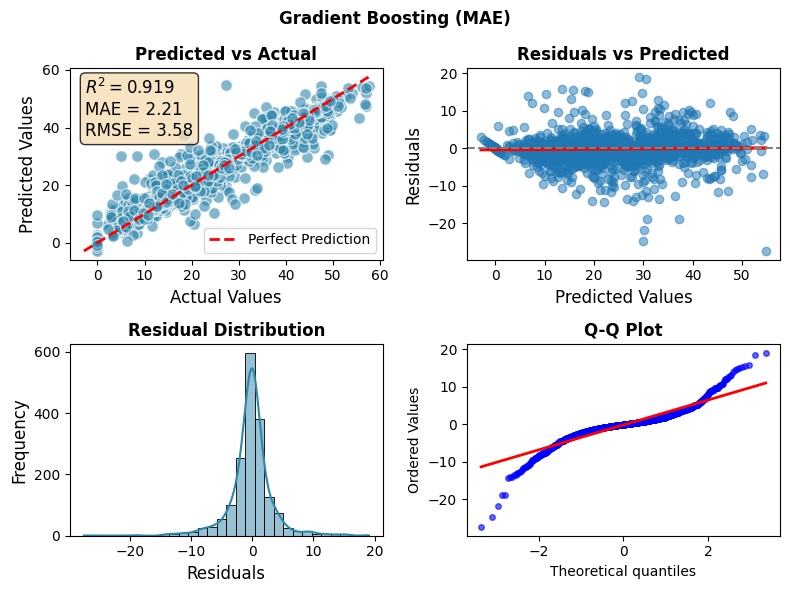

In [40]:
import pandas as pd
y_pred,gradient_boosting = comparacion.gradient_boosting(
                                                    best_params["gradient_boost"]["learning_rate"],
                                                    best_params["gradient_boost"]["max_depth"],
                                                    best_params["gradient_boost"]["n_estimators"],
                                                    loss="absolute_error")
tabla_comparativa_gradientboost=comparacion.create_entry(y_pred,"Gradient Boosting (MAE)",tabla_comparativa_gradientboost)
comparacion.plot_results(y_pred,"Gradient Boosting (MAE)")


In [41]:
tabla_comparativa_gradientboost

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,Gradient Boosting (MSE),1.9903,9.8680,3.1413,0.9373,0.9366
1,Gradient Boosting (MAE),2.2107,12.8237,3.5810,0.9186,0.9176


Tenemos que para `GradientBoost` MSE es mejor.

Ahora intentemos con el otro modelo que resultó ser muy bueno, `XGBoost`: 

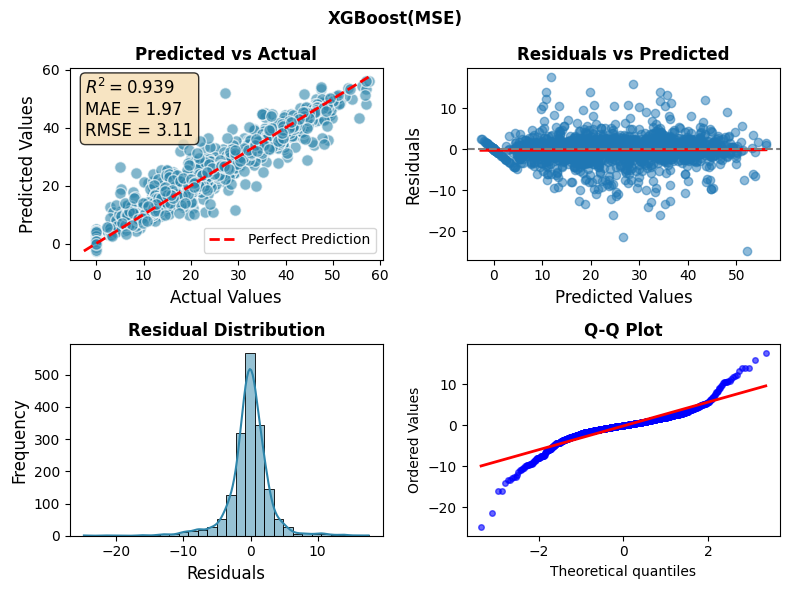

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,XGBoost (MSE),1.9682,9.6593,3.1079,0.9387,0.938


In [42]:
tabla_comparativa_xgboost = pd.DataFrame(columns=comparacion.columns_table)
y_pred,xgboost = comparacion.xg_boost(
                                                    best_params["xg_boost"]["learning_rate"],
                                                    best_params["xg_boost"]["max_depth"],
                                                    best_params["xg_boost"]["n_estimators"],
                                                    objective="reg:squarederror")
tabla_comparativa_xgboost=comparacion.create_entry(y_pred,"XGBoost (MSE)",tabla_comparativa_xgboost)
comparacion.plot_results(y_pred,"XGBoost(MSE)")
tabla_comparativa_xgboost

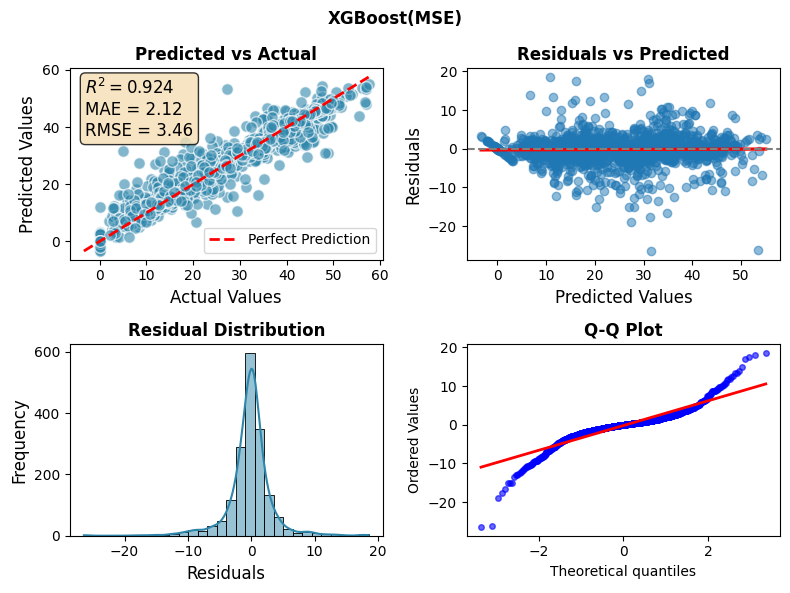

,Model,MAE,MSE,RMSE,R2_score,Adjusted_R2
0,XGBoost (MSE),1.9682,9.6593,3.1079,0.9387,0.9380
1,XGBoost (MSE),2.1192,11.9392,3.4553,0.9242,0.9233


In [43]:
y_pred,xgboost = comparacion.xg_boost(
                                                    best_params["xg_boost"]["learning_rate"],
                                                    best_params["xg_boost"]["max_depth"],
                                                    best_params["xg_boost"]["n_estimators"],
                                                    objective="reg:absoluteerror")
tabla_comparativa_xgboost=comparacion.create_entry(y_pred,"XGBoost (MSE)",tabla_comparativa_xgboost)
comparacion.plot_results(y_pred,"XGBoost(MSE)")
tabla_comparativa_xgboost

En ambos casos, correrlos con `MSE` resultó ser mejor. 

## Comparación de coeficientes
Vamos a comparar los coeficientes

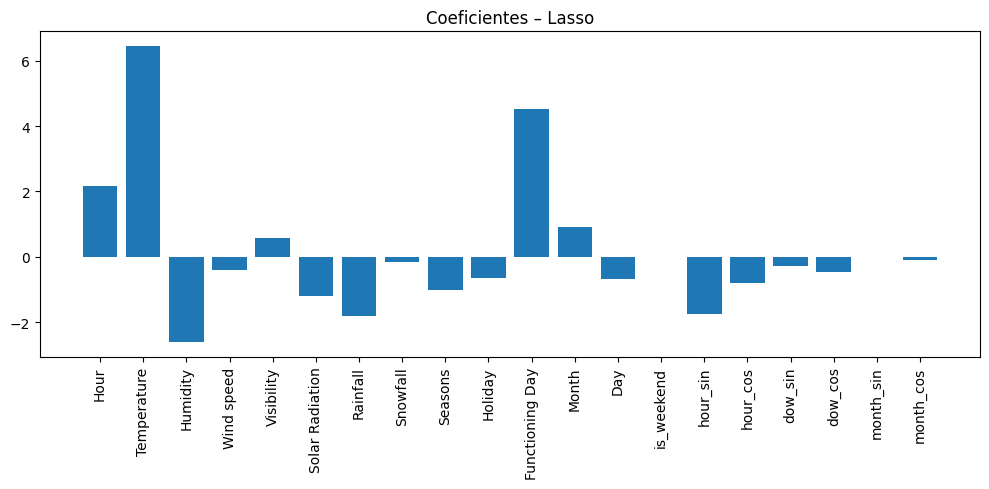

In [44]:
import matplotlib.pyplot as plt

coefs = lasso.coef_
features = comparacion.X.columns
plt.figure(figsize=(10,5))
plt.bar(features, coefs)
plt.xticks(rotation=90)
plt.title(f'Coeficientes – Lasso')
plt.tight_layout()
plt.show()


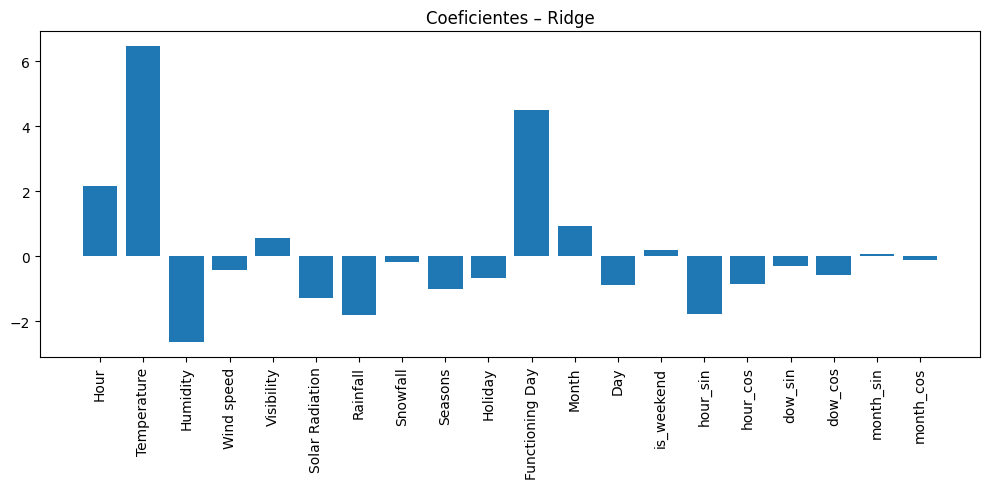

In [45]:

coefs = ridge.coef_
features = comparacion.X.columns
plt.figure(figsize=(10,5))
plt.bar(features, coefs)
plt.xticks(rotation=90)
plt.title(f'Coeficientes – Ridge')
plt.tight_layout()
plt.show()


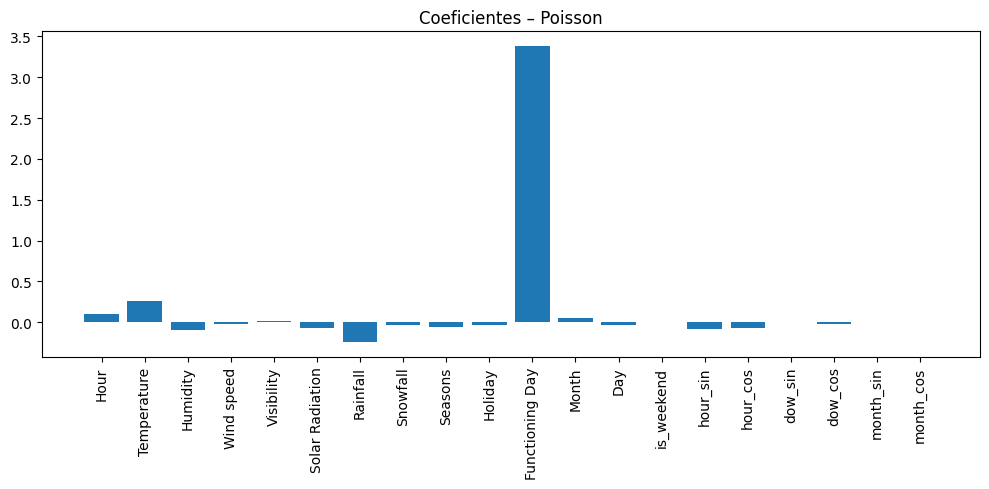

In [46]:

coefs = poisson.named_steps["poissonregressor"].coef_
features = comparacion.X.columns
plt.figure(figsize=(10,5))
plt.bar(features, coefs)
plt.xticks(rotation=90)
plt.title(f'Coeficientes – Poisson')
plt.tight_layout()
plt.show()


Podemos ver como `Lasso` manda a 0 a los features menos importantes. `Ridge` los acerca a 0. `Poisson` deja `Functioning Day` muy alto esto se debe a que esta variable binaria marca una diferencia drástica en la demanda: los días no hábiles presentan un alquiler casi nulo, frente a los días hábiles donde la demanda se dispara. Al estandarizar, el coeficiente representa el cambio en log-demanda por cada aumento de una desviación estándar (~0.4 unidades de la escala original), lo que sobrestima la magnitud aparente del efecto

## Conclusion:
Sorprendentemente, a pesar de haber un uso de justificado de una `GLM de Poisson`, esta no parece vencer a `Gradient Boost` , `Random Forest`, o a `XGBoost` pero sí vence a `Lasso`, `Ridge` y `Elastic Net`. Esto a pesar de haber incluido modificaciones para tomar en cuenta la estacionalidad temporal. 


A pesar de que una GLM de Poisson es teoricamente la más apropiada para datos de conteo, la presencia de no linealidad, interacciones entre variables, etc la hacen inferior a modelos basados en árboles o a los de redes en el perfomance de predicción. Esto se alinea con lo mencionado en clase y en otros estudios, que muestran que la flexibilidad de estos metodos ofrecen un mejor perfomance comparado con modelos parametricos a la hora de trabajar con data que tiene temporalidad estacional.

`GradientBoost` y `XGBoost` resultaron ser los mejores debido a la estructura compleja del dataset, que un modelo lineal no podría capturar. Estos modelos de boosting son especialmente buenos modelando relaciones no lineales y estacionalidad, estos modelos aprenden automáticamente las no linealidades como lo son las horas picos, el clima, etc. 

En resumen, `GradientBoost` y `XGBoost`  son los mejores porque aprenden de forma no paramétrica las no linealidades e interacciones presentes en los datos, y el proceso de boosting les da una gran capacidad predictiva sin caer en sobreajuste gracias a la regularización y al ajuste gradual de los residuos. Su flexibilidad y mecanismo de corrección secuencial son los más adecuados para la naturaleza de la demanda de bicicletas.
